In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("StudentsPerformance.csv")

In [3]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
1,female,group C,some college,standard,completed,69.0,90.0,88.0
2,female,group B,master's degree,standard,none,90.0,95.0,93.0
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,44.0
4,male,group C,some college,standard,none,76.0,78.0,75.0


In [4]:
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     6
reading score                  3
writing score                  4
dtype: int64

In [5]:
data['math score'] = data['math score'].fillna(data['math score'].mean())
data['reading score'] = data['reading score'].fillna(data['reading score'].mean())
data['writing score'] = data['writing score'].fillna(data['writing score'].mean())

In [6]:
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

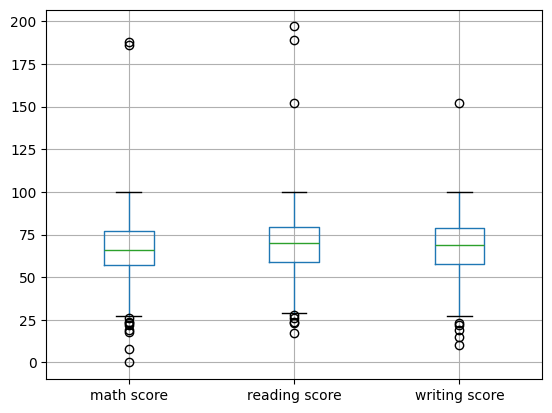

In [7]:
import matplotlib.pyplot as plt
data.boxplot(column = ['math score', 'reading score', 'writing score'])
plt.show()

In [8]:
# IQR for Math score
q1 = data['math score'].quantile(0.25)
q3 = data['math score'].quantile(0.75)
iqr = q3-q1

lower = q1-1.5*iqr
upper = q3+1.5*iqr

data=data[(data['math score']>=lower)&(data['math score']<= upper)]

# IQR for Math score
q1 = data['reading score'].quantile(0.25)
q3 = data['reading score'].quantile(0.75)
iqr = q3-q1

lower = q1-1.5*iqr
upper = q3+1.5*iqr

data=data[(data['reading score']>=lower)&(data['reading score']<= upper)]

# IQR for Math score
q1 = data['writing score'].quantile(0.25)
q3 = data['writing score'].quantile(0.75)
iqr = q3-q1

lower = q1-1.5*iqr
upper = q3+1.5*iqr

data=data[(data['writing score']>=lower)&(data['writing score']<= upper)]

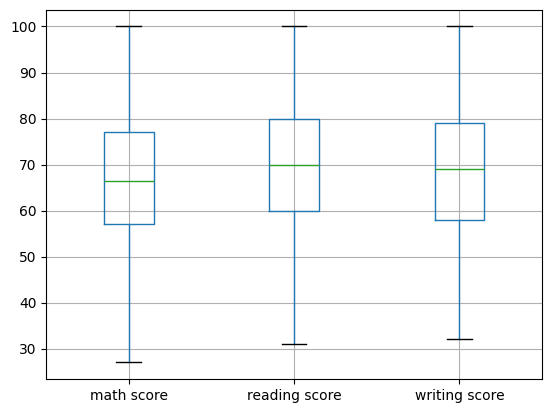

In [9]:
data.boxplot(column = ['math score', 'reading score', 'writing score'])
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data['gender'] = le.fit_transform(data['gender'])

data['gender'].value_counts()

gender
0    508
1    472
Name: count, dtype: int64

In [13]:
# Min Max Scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

data['math_scaled'] = scaler.fit_transform(data[['math score']])

data['read_scaled'] = scaler.fit_transform(data[['reading score']])

data['write_scaled'] = scaler.fit_transform(data[['writing score']])

In [16]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,math_scaled,read_scaled,write_scaled
0,0,group B,bachelor's degree,standard,none,72.0,72.0,74.0,0.616438,0.594203,0.617647
1,0,group C,some college,standard,completed,69.0,90.0,88.0,0.575342,0.855072,0.823529
2,0,group B,master's degree,standard,none,90.0,95.0,93.0,0.863014,0.927536,0.897059
3,1,group A,associate's degree,free/reduced,none,47.0,57.0,44.0,0.273973,0.376812,0.176471
4,1,group C,some college,standard,none,76.0,78.0,75.0,0.671233,0.681159,0.632353
